# Day 5 — Matplotlib & Week 1 Mini-Notebook

**Goal:**                  
● Create labeled line, scatter, bar, and histogram plots.           
● Combine multiple plots into one figure using subplots.                  
● Assemble a complete mini-notebook using NumPy, Pandas, and Matplotlib together.                   

---
## Step 1: Import Libraries
Let's start by importing the core data science libraries we will use: Matplotlib, NumPy, and Pandas.


In [90]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



---
## Step 2: Load and Inspect the Data
Now we will load the Titanic dataset (`tested.csv`) into a Pandas DataFrame and check its shape and structure.

In [91]:
df = pd.read_csv("tested.csv")
print("Dataset Shape:", df.shape) 
print("----------------------")
print("Dataset Info:")
df.info()

Dataset Shape: (418, 12)
----------------------
Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


---
### Step 3: Identify Missing Values
Before we can analyze our data, we need to see if any columns are missing information (contain `NaN` values).


In [92]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

---
### Step 4: Data Cleaning & Imputation
Based on our findings, we will:   
1. Drop the `Cabin` column (too many missing values).     
2. Fill the missing `Age` values with the overall average (Mean Imputation).     
3. Drop the single row missing a `Fare` value.      

In [93]:
df = df.drop(columns=["Cabin"])
df["Age"] = df["Age"].fillna(df["Age"].mean())
df = df.dropna(subset=["Fare"])

---
### Step 5: Use NumPy to compute at least one derived numeric
Here we use NumPy to calculate the average age. Then we create a boolean mask to filter for passengers older than the average, and finally group them by gender to see the demographic breakdown.

In [94]:
avg_age = np.mean(df['Age'])
mask = df['Age'] > avg_age
print("The mean Age on the Titanic was:", avg_age , "\n")
print("All values greater than 30.2:")
print(df[mask].groupby("Sex")["Age"].count())

The mean Age on the Titanic was: 30.20010256854757 

All values greater than 30.2:
Sex
female     75
male      142
Name: Age, dtype: int64


---
### Step 7: Data Visualization (Subplots Dashboard)
Finally, let's put it all together into a beautiful Matplotlib dashboard using `.subplots()`. We will visualize the Age distribution, survival counts, and relationships between variables!

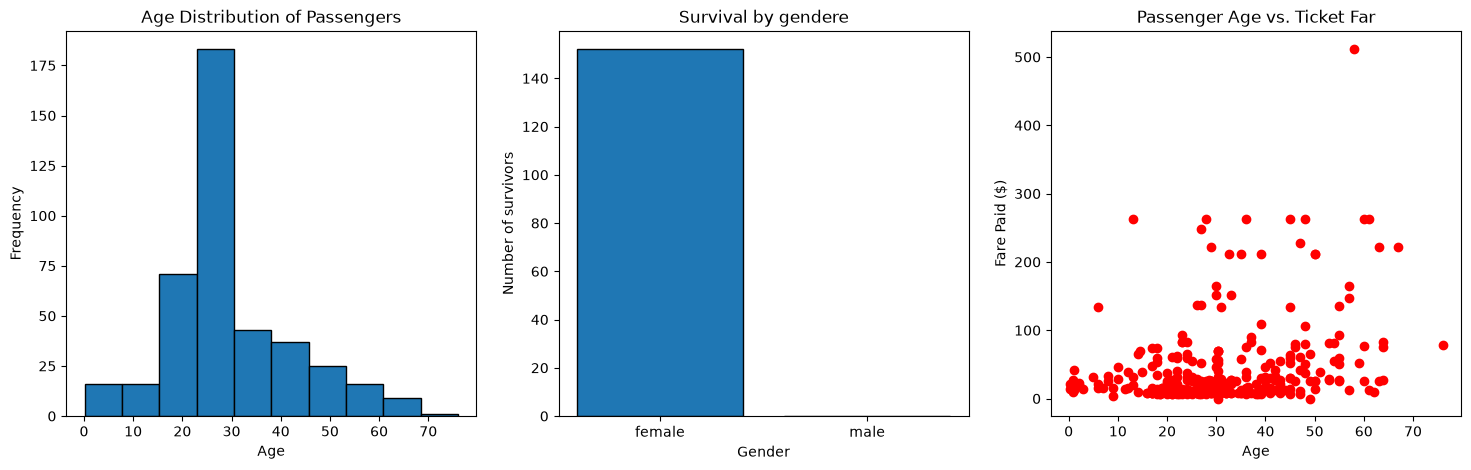

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(df['Age'], edgecolor='black')
axes[0].set_title("Age Distribution of Passengers")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

df_survival_by_gender = df.groupby("Sex")["Survived"].sum()

axes[1].bar(df_survival_by_gender.index, df_survival_by_gender.values, edgecolor='black')
axes[1].set_title("Survival by gendere")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Number of survivors")

axes[2].plot(df['Age'], df['Fare'], 'or')
axes[2].set_title("Passenger Age vs. Ticket Far")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Fare Paid ($)")
plt.show()
